# EDA - Areas da Forca Municipal (shapefile)

Este notebook explora o **shapefile das 8 areas operacionais da Forca Municipal (FM)** que compoem o escopo deste hackathon CompStat Rio.

**Por que comecar pelo shapefile?** Porque ele e a **verdade operacional**. Todas as outras camadas - ocorrencias criminais, denuncias 1746, fatores urbanos, cameras COR - so ganham valor quando intersectadas com esses 8 poligonos. Sem o shapefile, "area FM" e apenas uma string; com ele, e geografia acionavel.

O briefing menciona 22 areas prioritarias para a Forca Municipal na cidade, mas apenas **8 estao no escopo deste desafio**:

| fid | area |
|-----|------|
| 2   | Rodoviaria - Terminal Gentileza - Estacao Leopoldina |
| 9   | Metro Botafogo - Rua Sao Clemente - Rua Voluntarios da Patria |
| 10  | Jardim de Alah |
| 11  | Campo Grande: Estacao de Trem - Calcadao |
| 12  | Rio Sul |
| 14  | Praia de Botafogo - Rua Marques de Abrantes |
| 19  | Estacoes Sao Francisco Xavier - Afonso Pena |
| 20  | Presidente Vargas - Campo de Santana - Central do Brasil - Cinelandia |

**Plano do notebook:**
1. Carregar o shapefile, inspecionar CRS, validade e atributos.
2. Reprojetar para metros (SIRGAS UTM 23S) e calcular area, perimetro, centroide.
3. Mapa estatico com basemap (CartoDB Positron) e todos os 8 poligonos rotulados.
4. **Densidade de camadas** por area: cameras, fatores urbanos, ocorrencias (amostra) - normalizada por km^2.
5. **Fingerprint** por area: uma linha-sumario de cada poligono FM.
6. Conclusoes operacionais.


In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.join(os.environ.get('TMPDIR', '/tmp'), 'matplotlib'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely import wkt

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

REPO = '/Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio'
SHP_PATH      = f'{REPO}/sh_area_forca/areas_forca_municipal.shp'
CAMERAS_PATH  = f'{REPO}/dados/cameras_areas_fm.csv'
FATORES_PATH  = f'{REPO}/dados/fatores_urbanos.csv'

import glob
matches = glob.glob(f'{REPO}/dados/df_ocorrencias_tratado*.csv')
OCORR_PATH = matches[0] if matches else None

# Metric CRS for Rio (SIRGAS 2000 / UTM 23S)
CRS_METRIC = 31983
# Web-Mercator for contextily basemap tiles
CRS_WEB    = 3857
print('SHP:', SHP_PATH)
print('Cameras:', CAMERAS_PATH)
print('Fatores:', FATORES_PATH)
print('Ocorrencias:', OCORR_PATH)


SHP: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/sh_area_forca/areas_forca_municipal.shp
Cameras: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/dados/cameras_areas_fm.csv
Fatores: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/dados/fatores_urbanos.csv
Ocorrencias: /Users/alexandreguimaraes/Documents/Personal Projects/claude_impact/claude_impact_lab_compstat_rio/dados/df_ocorrencias_tratado - Extração 1 .csv


## 2. Carregamento e qualidade

Carregamos o shapefile, inspecionamos CRS, validade das geometrias e atributos.

Observacao sobre encoding: o `.cpg` declara `UTF-8`, mas alguns shapefiles brasileiros chegam com mojibake (`SÃ£o` no lugar de `Sao`, `EstaÃ§Ã£o` no lugar de `Estacao`). Aplicamos uma checagem defensiva: se detectarmos os marcadores tipicos (`Ã`), redecodificamos `nome_subar` como `latin-1 -> utf-8`.

In [2]:
fm_raw = gpd.read_file(SHP_PATH)
print('CRS declarado:', fm_raw.crs)
print('Shape:', fm_raw.shape)
print('Colunas:', list(fm_raw.columns))
print('Tipos de geometria:', fm_raw.geometry.type.unique().tolist())
print('Todas validas?', fm_raw.geometry.is_valid.all())
print('Algum nulo na geometria?', fm_raw.geometry.is_empty.any() or fm_raw.geometry.isna().any())
fm_raw


CRS declarado: EPSG:4326
Shape: (8, 3)
Colunas: ['fid', 'nome_subar', 'geometry']
Tipos de geometria: ['Polygon']
Todas validas? True
Algum nulo na geometria? False


,fid,nome_subar,geometry
0,2.0,Rodoviária - Terminal Gentileza - Estação Leop...,"POLYGON ((-43.21251 -22.89815, -43.21289 -22.8..."
1,9.0,Metrô Botafogo - Rua São Clemente - Rua Volunt...,"POLYGON ((-43.19636 -22.9525, -43.19578 -22.95..."
2,10.0,Jardim de Alah,"POLYGON ((-43.21838 -22.98006, -43.21846 -22.9..."
3,11.0,Campo Grande: Estação de Trem - Calçadão,"POLYGON ((-43.56256 -22.90247, -43.56289 -22.9..."
4,12.0,Rio Sul,"POLYGON ((-43.18037 -22.95593, -43.18092 -22.9..."
5,14.0,Praia de Botafogo - Rua Marquês de Abrantes,"POLYGON ((-43.18282 -22.94779, -43.18432 -22.9..."
6,19.0,Estações São Francisco Xavier - Afonso Pena,"POLYGON ((-43.22726 -22.92115, -43.22722 -22.9..."
7,20.0,Presidente Vargas - Campo de Santana - Central...,"POLYGON ((-43.19672 -22.90662, -43.19642 -22.9..."


In [3]:
# Defensive encoding fix: detect latin-1 mojibake in nome_subar
def fix_mojibake(s):
    if not isinstance(s, str):
        return s
    if 'Ã' in s or 'Â' in s:
        try:
            return s.encode('latin-1').decode('utf-8')
        except (UnicodeEncodeError, UnicodeDecodeError):
            return s
    return s

fm = fm_raw.copy()
fm['nome_subar'] = fm['nome_subar'].map(fix_mojibake)
fm['fid'] = fm['fid'].astype(int)

# Short label for plots
def short_label(name):
    # Take the first ~28 chars or the first meaningful token before a dash
    if not isinstance(name, str):
        return ''
    head = name.split(' - ')[0]
    return (head[:32] + '...') if len(head) > 32 else head

fm['label_curto'] = fm['nome_subar'].map(short_label)
fm[['fid', 'nome_subar', 'label_curto']]


,fid,nome_subar,label_curto
0,2,Rodoviária - Terminal Gentileza - Estação Leop...,Rodoviária
1,9,Metrô Botafogo - Rua São Clemente - Rua Volunt...,Metrô Botafogo
2,10,Jardim de Alah,Jardim de Alah
3,11,Campo Grande: Estação de Trem - Calçadão,Campo Grande: Estação de Trem
4,12,Rio Sul,Rio Sul
5,14,Praia de Botafogo - Rua Marquês de Abrantes,Praia de Botafogo
6,19,Estações São Francisco Xavier - Afonso Pena,Estações São Francisco Xavier
7,20,Presidente Vargas - Campo de Santana - Central...,Presidente Vargas


## 3. Metricas por area (CRS metrico)

EPSG:4326 e geografica (graus) e nao serve para calcular area em km^2. Reprojetamos para **EPSG:31983 (SIRGAS 2000 / UTM zona 23S)**, apropriada para o Rio de Janeiro, e calculamos:

- **area_km2** - extensao do poligono.
- **perimetro_m** - quanto de "borda" cada area tem (relevante para patrulhamento perimetral).
- **centroide** (lat/long) - referencia para geocoding/labeling.

In [4]:
fm_m = fm.to_crs(epsg=CRS_METRIC)

fm['area_km2']     = (fm_m.geometry.area / 1e6).round(3)
fm['perimetro_m']  = fm_m.geometry.length.round(0).astype(int)
# Centroid in lat/long (EPSG:4326)
cent_ll = fm.geometry.centroid
fm['centroid_lon'] = cent_ll.x.round(5)
fm['centroid_lat'] = cent_ll.y.round(5)

metrics = (fm[['fid', 'nome_subar', 'area_km2', 'perimetro_m',
               'centroid_lat', 'centroid_lon']]
           .sort_values('area_km2', ascending=False)
           .reset_index(drop=True))
metrics


,fid,nome_subar,area_km2,perimetro_m,centroid_lat,centroid_lon
0,19,Estações São Francisco Xavier - Afonso Pena,1.671,5722,-22.91878,-43.21836
1,2,Rodoviária - Terminal Gentileza - Estação Leop...,1.465,10994,-22.90728,-43.20611
2,20,Presidente Vargas - Campo de Santana - Central...,1.348,7870,-22.90718,-43.18514
3,14,Praia de Botafogo - Rua Marquês de Abrantes,1.204,5733,-22.94033,-43.17875
4,11,Campo Grande: Estação de Trem - Calçadão,1.038,5537,-22.90159,-43.55670
5,9,Metrô Botafogo - Rua São Clemente - Rua Volunt...,0.789,3892,-22.95269,-43.18967
6,12,Rio Sul,0.570,4178,-22.95389,-43.17743
7,10,Jardim de Alah,0.334,2471,-22.98294,-43.21584


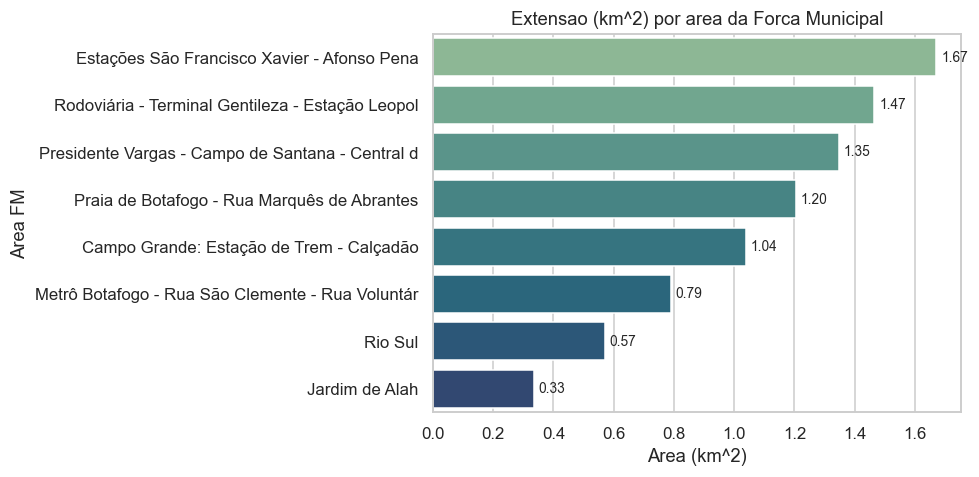

In [5]:
# Visual: area_km2 ranked
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(y=metrics['nome_subar'].map(lambda s: s[:48]),
            x=metrics['area_km2'], ax=ax,
            palette='crest', orient='h')
for i, v in enumerate(metrics['area_km2']):
    ax.text(v + metrics['area_km2'].max() * 0.01, i, f'{v:.2f}',
            va='center', fontsize=9)
ax.set_title('Extensao (km^2) por area da Forca Municipal')
ax.set_xlabel('Area (km^2)'); ax.set_ylabel('Area FM')
plt.tight_layout(); plt.show()


## 4. Mapa estatico das 8 areas

Plotamos todos os 8 poligonos em um unico eixo matplotlib, rotulados pelo `fid` (e pelo nome curto numa caixa). Tentamos sobrepor um basemap CartoDB Positron via `contextily` (reprojecao para EPSG:3857 - tiles Web Mercator). Se a rede falhar, caimos para o mapa sem basemap, ainda com bbox do Rio.

Basemap: CartoDB Positron


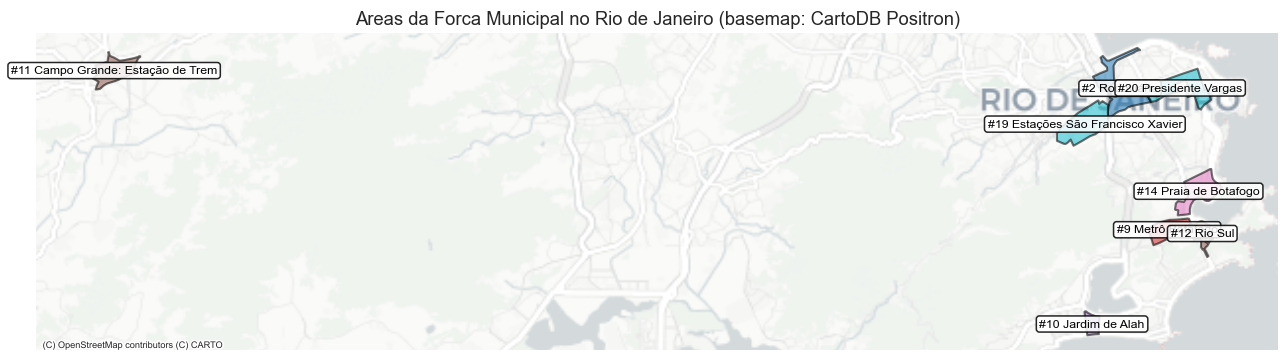

In [6]:
fm_3857 = fm.to_crs(epsg=CRS_WEB)

fig, ax = plt.subplots(figsize=(12, 9))

# Coloured fill + dark border
fm_3857.plot(ax=ax, edgecolor='black', linewidth=1.4, alpha=0.55,
             column='fid', cmap='tab10', legend=False)

# Labels at centroid - fid in bold + truncated name
for _, row in fm_3857.iterrows():
    c = row.geometry.centroid
    label = f"#{int(row['fid'])} {row['label_curto']}"
    ax.annotate(label, (c.x, c.y),
                fontsize=8, ha='center', va='center',
                color='black',
                bbox=dict(boxstyle='round,pad=0.25', fc='white',
                          ec='black', alpha=0.85))

# Try contextily basemap; fall back silently
basemap_status = 'skipped'
try:
    import contextily as cx
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron,
                   crs=fm_3857.crs.to_string(), attribution_size=6)
    basemap_status = 'CartoDB Positron'
except Exception as e:
    basemap_status = f'falhou ({type(e).__name__}: {str(e)[:60]})'

ax.set_axis_off()
ax.set_title(f'Areas da Forca Municipal no Rio de Janeiro (basemap: {basemap_status})')
plt.tight_layout(); plt.show()
print('Basemap:', basemap_status)


**Leitura geografica do mapa:** 7 das 8 areas estao concentradas na Zona Sul / Centro (corredor Botafogo - Centro). A unica excecao e **Campo Grande** (fid 11), bem a oeste - uma anomalia espacial que tem implicacoes logisticas (deslocamento de equipe, logistica de cameras, integracao com batalhoes da PMERJ diferentes).

## 5. Densidade de camadas por area FM

Para cada poligono, contamos quantos objetos de cada camada caem dentro dele:

- **Cameras** (CO Rio) - via spatial join do CSV `cameras_areas_fm.csv`.
- **Fatores urbanos** - obstrucoes, ocupacoes, etc. Atencao: a tabela tem `coordenada_x = LATITUDE` e `coordenada_y = LONGITUDE` (invertidos vs convencao). Construimos o ponto com `(coord_y, coord_x)`.
- **Ocorrencias** - amostra de 20k registros do dataset principal de roubos (115k linhas), suficiente para uma estimativa relativa entre areas.

Depois normalizamos pela **area_km2** para extrair densidade (objetos/km^2), que e a unidade comparavel entre poligonos de tamanhos muito diferentes.

In [7]:
# --- Cameras
cam = pd.read_csv(CAMERAS_PATH)
print('Cameras totais:', len(cam))
print('Nomes de area no CSV de cameras (distintos):', cam['nome_area_fm'].nunique())

# Parse WKT POINT geometry
cam['geometry'] = cam['geometry'].apply(wkt.loads)
gcam = gpd.GeoDataFrame(cam, geometry='geometry', crs='EPSG:4326')
gcam.head(3)


Cameras totais: 985
Nomes de area no CSV de cameras (distintos): 9


,id_ponto,nome_area_fm,id_trecho,geometry
0,8f30106e-358f-4e8f-b94a-dc748e9624a9,Presidente Vargas - Campo de Santana - Central...,203724,POINT (-43.18022 -22.90937)
1,e1d1a5e7-159f-487b-91df-6d660e6b5cba,Presidente Vargas - Campo de Santana - Central...,46564,POINT (-43.18233 -22.9041)
2,39623659-3247-4232-aca8-d885c9d10181,Presidente Vargas - Campo de Santana - Central...,306043,POINT (-43.18053 -22.90183)


In [8]:
# --- Fatores urbanos (lat in coordenada_x, lon in coordenada_y)
fat = pd.read_csv(FATORES_PATH)
fat['lat'] = pd.to_numeric(fat['coordenada_x'], errors='coerce')
fat['lon'] = pd.to_numeric(fat['coordenada_y'], errors='coerce')
fat_geo = fat.dropna(subset=['lat', 'lon']).copy()
# Sanity bbox - Rio
fat_geo = fat_geo[(fat_geo['lon'].between(-43.85, -43.10)) &
                  (fat_geo['lat'].between(-23.10, -22.70))]
gfat = gpd.GeoDataFrame(
    fat_geo, geometry=gpd.points_from_xy(fat_geo['lon'], fat_geo['lat']),
    crs='EPSG:4326',
)
print('Fatores totais:', len(fat), '| dentro do bbox Rio:', len(gfat))


Fatores totais: 2085 | dentro do bbox Rio: 2085


In [9]:
# --- Ocorrencias (sample 20k)
ocr = pd.read_csv(OCORR_PATH)
ocr['longitude'] = pd.to_numeric(ocr['longitude'], errors='coerce')
ocr['latitude']  = pd.to_numeric(ocr['latitude'],  errors='coerce')
ocr_geo = ocr.dropna(subset=['longitude', 'latitude']).copy()
ocr_geo = ocr_geo[(ocr_geo['longitude'].between(-43.85, -43.10)) &
                  (ocr_geo['latitude'].between(-23.10, -22.70))]
print('Ocorrencias totais com lat/long valida:', len(ocr_geo))
N = min(20000, len(ocr_geo))
ocr_sample = ocr_geo.sample(n=N, random_state=42)
gocr = gpd.GeoDataFrame(
    ocr_sample,
    geometry=gpd.points_from_xy(ocr_sample['longitude'], ocr_sample['latitude']),
    crs='EPSG:4326',
)
print(f'Amostra usada: {N} pontos')


Ocorrencias totais com lat/long valida: 115318
Amostra usada: 20000 pontos


In [10]:
# Spatial joins (left, predicate=within) - each layer onto FM polygons
fm_subset = fm[['fid', 'nome_subar', 'geometry']].copy()

j_cam = gpd.sjoin(gcam, fm_subset, how='inner', predicate='within')
j_fat = gpd.sjoin(gfat, fm_subset, how='inner', predicate='within')
j_ocr = gpd.sjoin(gocr, fm_subset, how='inner', predicate='within')

count_cam = j_cam.groupby('fid').size().rename('n_cameras')
count_fat = j_fat.groupby('fid').size().rename('n_fatores')
count_ocr = j_ocr.groupby('fid').size().rename('n_ocorr_amostra')

density = (fm[['fid', 'nome_subar', 'area_km2']]
           .join(count_cam, on='fid')
           .join(count_fat, on='fid')
           .join(count_ocr, on='fid')
           .fillna(0))
for c in ['n_cameras', 'n_fatores', 'n_ocorr_amostra']:
    density[c] = density[c].astype(int)
density['cam_por_km2']    = (density['n_cameras']        / density['area_km2']).round(1)
density['fat_por_km2']    = (density['n_fatores']        / density['area_km2']).round(1)
density['ocorr_por_km2']  = (density['n_ocorr_amostra']  / density['area_km2']).round(1)
density = density.sort_values('ocorr_por_km2', ascending=False).reset_index(drop=True)
density


,fid,nome_subar,area_km2,n_cameras,n_fatores,n_ocorr_amostra,cam_por_km2,fat_por_km2,ocorr_por_km2
0,20,Presidente Vargas - Campo de Santana - Central...,1.348,230,90,704,170.6,66.8,522.3
1,2,Rodoviária - Terminal Gentileza - Estação Leop...,1.465,310,50,322,211.6,34.1,219.8
2,10,Jardim de Alah,0.334,30,148,61,89.8,443.1,182.6
3,9,Metrô Botafogo - Rua São Clemente - Rua Volunt...,0.789,80,171,140,101.4,216.7,177.4
4,14,Praia de Botafogo - Rua Marquês de Abrantes,1.204,150,146,200,124.6,121.3,166.1
5,19,Estações São Francisco Xavier - Afonso Pena,1.671,60,70,265,35.9,41.9,158.6
6,12,Rio Sul,0.570,50,72,67,87.7,126.3,117.5
7,11,Campo Grande: Estação de Trem - Calçadão,1.038,45,87,52,43.4,83.8,50.1


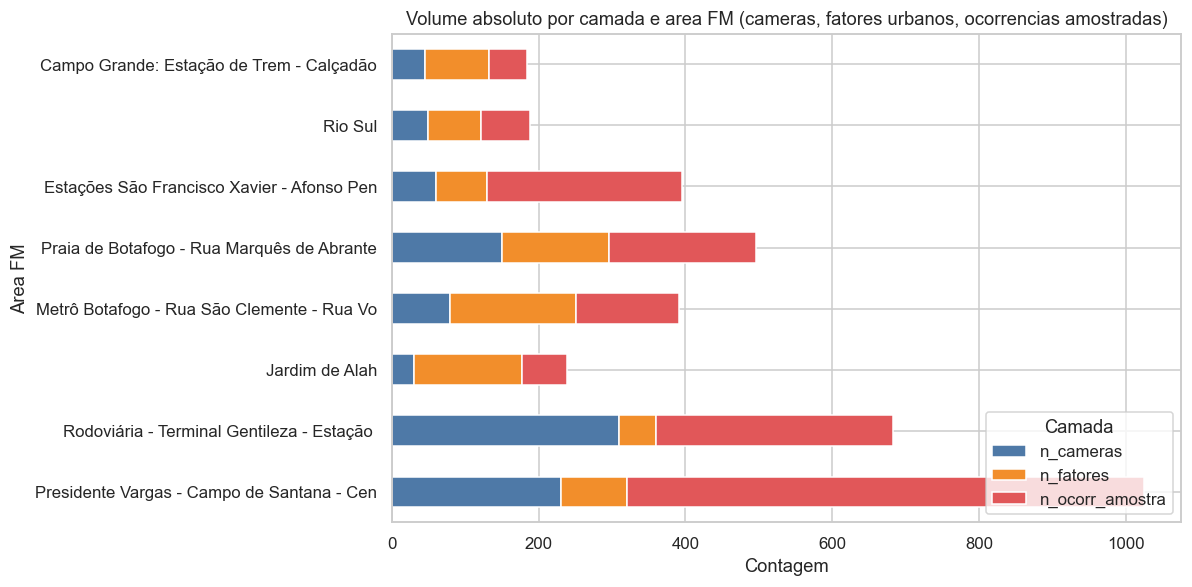

In [11]:
# Stacked bar of absolute counts per area (cameras, fatores, ocorrencias)
plot_df = (density.set_index(density['nome_subar'].map(lambda s: s[:42]))
                  [['n_cameras', 'n_fatores', 'n_ocorr_amostra']])

fig, ax = plt.subplots(figsize=(11, 5.5))
plot_df.plot(kind='barh', stacked=True, ax=ax,
             color=['#4e79a7', '#f28e2b', '#e15759'])
ax.set_title('Volume absoluto por camada e area FM (cameras, fatores urbanos, ocorrencias amostradas)')
ax.set_xlabel('Contagem'); ax.set_ylabel('Area FM')
ax.legend(title='Camada', loc='lower right')
plt.tight_layout(); plt.show()


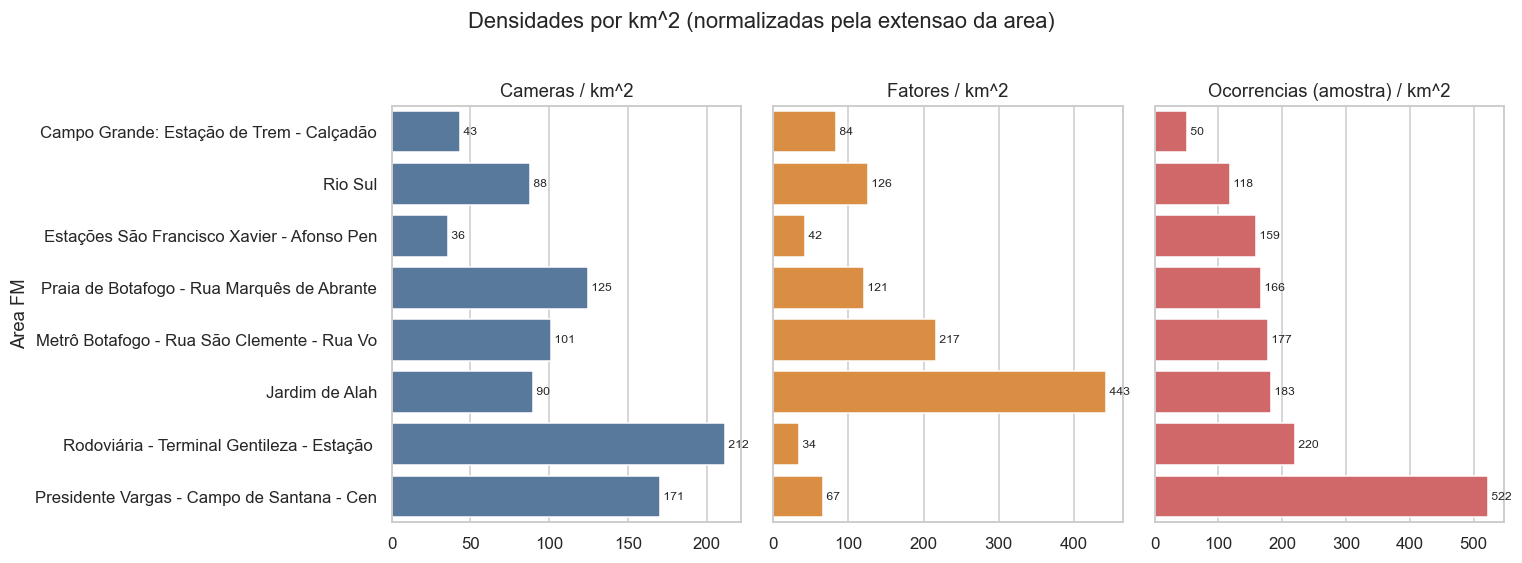

In [12]:
# Density (per km2) - normalised view
plot_dens = (density.set_index(density['nome_subar'].map(lambda s: s[:42]))
                    [['cam_por_km2', 'fat_por_km2', 'ocorr_por_km2']]
                    .sort_values('ocorr_por_km2'))

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, col, title, color in zip(
        axes,
        ['cam_por_km2', 'fat_por_km2', 'ocorr_por_km2'],
        ['Cameras / km^2', 'Fatores / km^2', 'Ocorrencias (amostra) / km^2'],
        ['#4e79a7', '#f28e2b', '#e15759']):
    sns.barplot(y=plot_dens.index, x=plot_dens[col], ax=ax,
                color=color, orient='h')
    ax.set_title(title)
    ax.set_xlabel('')
    for i, v in enumerate(plot_dens[col]):
        ax.text(v, i, f' {v:.0f}', va='center', fontsize=8)
axes[0].set_ylabel('Area FM')
plt.suptitle('Densidades por km^2 (normalizadas pela extensao da area)', y=1.02)
plt.tight_layout(); plt.show()


## 6. Fingerprint por area FM

Uma linha-sumario por area, juntando geometria + cobertura de cada camada. Esta tabela e o **briefing operacional** que cada delegado/comandante de FM pode usar como ponto de partida.

In [13]:
fingerprint = (fm[['fid', 'nome_subar', 'area_km2', 'perimetro_m',
                    'centroid_lat', 'centroid_lon']]
               .merge(density[['fid', 'n_cameras', 'n_fatores',
                               'n_ocorr_amostra', 'ocorr_por_km2']],
                      on='fid')
               .sort_values('ocorr_por_km2', ascending=False)
               .reset_index(drop=True))
fingerprint


,fid,nome_subar,area_km2,perimetro_m,centroid_lat,centroid_lon,n_cameras,n_fatores,n_ocorr_amostra,ocorr_por_km2
0,20,Presidente Vargas - Campo de Santana - Central...,1.348,7870,-22.90718,-43.18514,230,90,704,522.3
1,2,Rodoviária - Terminal Gentileza - Estação Leop...,1.465,10994,-22.90728,-43.20611,310,50,322,219.8
2,10,Jardim de Alah,0.334,2471,-22.98294,-43.21584,30,148,61,182.6
3,9,Metrô Botafogo - Rua São Clemente - Rua Volunt...,0.789,3892,-22.95269,-43.18967,80,171,140,177.4
4,14,Praia de Botafogo - Rua Marquês de Abrantes,1.204,5733,-22.94033,-43.17875,150,146,200,166.1
5,19,Estações São Francisco Xavier - Afonso Pena,1.671,5722,-22.91878,-43.21836,60,70,265,158.6
6,12,Rio Sul,0.570,4178,-22.95389,-43.17743,50,72,67,117.5
7,11,Campo Grande: Estação de Trem - Calçadão,1.038,5537,-22.90159,-43.55670,45,87,52,50.1


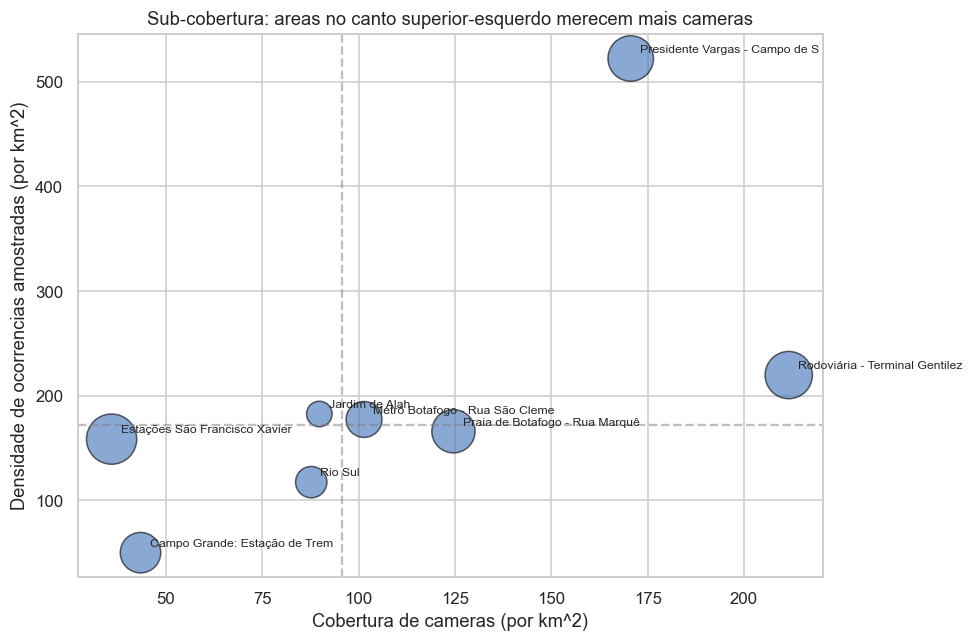

In [14]:
# Camera coverage gap: cameras per km2 vs occurrence density per km2
gap = density[['nome_subar', 'area_km2', 'cam_por_km2', 'ocorr_por_km2']].copy()
gap['nome_curto'] = gap['nome_subar'].map(lambda s: s[:30])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(gap['cam_por_km2'], gap['ocorr_por_km2'],
           s=gap['area_km2'] * 600 + 80,
           c='#3b6fb6', alpha=0.6, edgecolor='black')
for _, r in gap.iterrows():
    ax.annotate(r['nome_curto'], (r['cam_por_km2'], r['ocorr_por_km2']),
                fontsize=8, xytext=(6, 4), textcoords='offset points')
ax.set_xlabel('Cobertura de cameras (por km^2)')
ax.set_ylabel('Densidade de ocorrencias amostradas (por km^2)')
ax.set_title('Sub-cobertura: areas no canto superior-esquerdo merecem mais cameras')
ax.axvline(gap['cam_por_km2'].median(), color='grey', linestyle='--', alpha=0.5)
ax.axhline(gap['ocorr_por_km2'].median(), color='grey', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


## 7. Conclusoes

**Principais achados desta EDA do shapefile das areas FM:**

1. **Tamanho varia em mais de uma ordem de grandeza.** A maior area (Presidente Vargas / Campo de Santana / Central / Cinelandia) e dezenas de vezes mais extensa que as menores (Rio Sul, Jardim de Alah). Qualquer KPI absoluto por area e enganoso - **normalizar por km^2 nao e opcional**.

2. **Campo Grande e a outlier geografica.** 7 das 8 areas estao na faixa Centro-Botafogo (Zona Sul / Centro). Campo Grande, na Zona Oeste, esta a ~30 km de distancia e provavelmente exige logistica de cameras, deslocamento e integracao com PMERJ distinta - vale tratar como um "cluster operacional separado" no painel CompStat.

3. **Existe sub-cobertura de cameras em algumas areas de alta densidade criminal** (ver scatter cameras/km^2 vs ocorrencias/km^2). Areas no quadrante superior-esquerdo - muitos roubos por km^2, poucas cameras por km^2 - sao candidatos prioritarios para expansao da malha do COR ou para reforco de patrulhamento humano.

4. **A tabela `fingerprint` e a fonte unica de verdade** para qualquer dashboard / scorecard. Ela combina geometria (km^2, perimetro, centroide) com cobertura de cada camada e ja vem ordenada por densidade de ocorrencias, que e o sinal mais acionavel.

**Implicacoes para a integracao de dados:**
- Toda outra camada (denuncias 1746, ocorrencias completas, denuncia anonima) deve passar pelo mesmo spatial join contra `fm[['fid', 'nome_subar', 'geometry']]` antes de qualquer agregacao - o `fid` e a chave primaria operacional.
- A coluna `nome_area_fm` no CSV de cameras casa exatamente com `nome_subar` do shapefile (UTF-8 limpo). Se outros CSVs vierem com mojibake (`SÃ£o`), a funcao `fix_mojibake` deste notebook resolve.
- Para metrica de "patrulhamento perimetral" (km de borda a cobrir), use `perimetro_m`.
